# Double Mass Spring System: Results Visualization

This notebook evaluates and visualizes trained models for the double mass spring system with encoder-learned initial conditions.

**Capabilities:**
1. Error metrics over time (mean ± std and percentiles)
2. 1D trajectory visualizations
3. Cumulative error analysis
4. Training/validation loss visualization

In [1]:
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence, Tuple

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import json

from utilities import Params, load_model, integrate_vector_field
from models import HamiltonianNN, NeuralODE, ICEncoder
from vector_fields import (
    vector_field_double_mass_spring,
    vector_field_hnn_potenergy,
    vector_field_hnn_totenergy,
    vector_field_node_phys,
    vector_field_node_vanilla,
)

In [2]:
# Initialize RNG
key = jax.random.PRNGKey(42)

## 2. Plotting Configuration

In [3]:
# Font settings
plt.rcParams['font.size'] = 20
plt.rcParams['font.family'] = 'sans-serif'

# Color palette
COLORS = {
    "hnn_pot": "#2160B3",      # Blue
    "hnn_tot": "#74c6ec",      # Cyan  
    "node_phys": "#f0c37c",    # Red
    "node_vanilla": "#D27146", # Yellow
    "true": "#777777",         # Grey
}

LABELS = {
    "hnn_pot": "NHODE$_{\\mathrm{pot}}$",
    "hnn_tot": "NHODE$_{\\mathrm{tot}}$",
    "node_phys": "NODE$_{\\mathrm{phys}}$",
    "node_vanilla": "NODE$_{\\mathrm{vanilla}}$",
    "true": "Ground truth",
}

## 3. Configuration & System Parameters

In [4]:

def load_metadata(seed_dir: Path, method: str) -> dict:
    """
    Load metadata JSON file from checkpoint directory.
    
    Parameters
    ----------
    seed_dir : Path
        Checkpoint directory containing metadata file
    method : str
        Method name (used in filename)
        
    Returns
    -------
    metadata : dict
        Model configuration and training metadata containing:
        - model_type: str
        - epochs, batch_size, learning rates
        - hidden_dim, depth (model architecture)
        - conditioning_steps, encoder_hidden_dim, encoder_depth
        - system_params: dict with m0, m1, k0, k1, L0, L1
        - training data info: n_trajectories, trajectory_length, etc.
        - timestamp and seed
    """
    metadata_path = seed_dir / f"two_mass_spring_{method}_metadata.json"
    
    if metadata_path.exists():
        with open(metadata_path, 'r') as f:
            return json.load(f)
    else:
        print(f"Warning: Metadata file not found at {metadata_path}")
        return None


In [5]:
# Checkpoint directory
CKPT_DIR = Path("checkpoints/without_regularisation")

metadata = load_metadata(Path("checkpoints/with_regularisation/hnn_pot/seed_0"), "hnn_pot")

In [6]:
# Simulation parameters

ROLLOUT_FACTOR = 20

T_FINAL = metadata['trajectory_length'] * ROLLOUT_FACTOR
N_TIMESTEPS = (metadata['trajectory_steps'] - 1) * ROLLOUT_FACTOR + 1

In [7]:
# System parameters (must match training)
system_params = Params(
    m0=metadata['system_params']['m0'],
    m1=metadata['system_params']['m1'],
    k0=metadata['system_params']['k0'],
    k1=metadata['system_params']['k1'],
    L0=metadata['system_params']['L0'],
    L1=metadata['system_params']['L1'],
)

# Test data configuration
N_TEST_TRAJECTORIES = 10  # Number of initial conditions to test

# Encoder configuration
CONDITIONING_STEPS = metadata['conditioning_steps']                # Observation window for encoder
OBSERVED_INDICES = jnp.array([0, 2])   # Observe first mass only

## 4. Helper Functions

### 4.1 Initial Condition Sampling

In [8]:
def sample_initial_conditions(key: jax.random.PRNGKey, n_samples: int):
    """
    Sample initial conditions for the double mass spring system.
    
    State format: [x0, x1, v0, v1]
    
    Returns
    -------
    y0s : array [n_samples, 4]
        Initial conditions
    """
    k1, k2, k3, k4 = jax.random.split(key, 4)
    x0 = jax.random.uniform(k1, (n_samples,), minval=0.2, maxval=0.8)
    x1 = jax.random.uniform(k3, (n_samples,), minval=0.9, maxval=1.4)
    v0 = jax.random.uniform(k2, (n_samples,), minval=-0.7, maxval=0.7)
    v1 = jax.random.uniform(k4, (n_samples,), minval=-0.7, maxval=0.7)
    return jnp.stack([x0, x1, v0, v1], axis=-1)

### 4.2 Model Loading and Simulation

In [9]:
def get_model_skeleton(method: str, key: jax.random.PRNGKey):
    """
    Create a model skeleton for loading saved weights.
    
    Parameters
    ----------
    method : str
        One of: 'hnn_pot', 'hnn_tot', 'node_phys', 'node_vanilla'
    key : PRNGKey
        Random key for initialization
        
    Returns
    -------
    model_like : Model
        Empty model with correct architecture
    """
    hidden_dim = metadata['hidden_dim']
    depth = metadata['depth']
    
    if method == "hnn_pot":
        return HamiltonianNN(input_dim=2, key=key, hidden_dim=hidden_dim, depth=depth)
    elif method == "hnn_tot":
        return HamiltonianNN(input_dim=4, key=key, hidden_dim=hidden_dim, depth=depth)
    elif method == "node_phys":
        return NeuralODE(input_dim=4, output_dim=2, key=key, hidden_dim=hidden_dim, depth=depth)
    elif method == "node_vanilla":
        return NeuralODE(input_dim=4, output_dim=4, key=key, hidden_dim=hidden_dim, depth=depth)
    else:
        raise ValueError(f"Unknown method: {method}")

def get_encoder_skeleton(key: jax.random.PRNGKey):
    """Create encoder skeleton for loading weights."""
    return ICEncoder(
        key=key,
        conditioning_steps=CONDITIONING_STEPS,
        hidden_dim=metadata['encoder_hidden_dim'],
        depth=metadata['encoder_depth']
    )

In [10]:

def get_vector_field(method: str):
    """
    Get the appropriate vector field function for a method.
    """
    vector_fields = {
        "hnn_pot": vector_field_hnn_potenergy,
        "hnn_tot": vector_field_hnn_totenergy,
        "node_phys": vector_field_node_phys,
        "node_vanilla": vector_field_node_vanilla,
        "true": vector_field_double_mass_spring,
    }
    return vector_fields[method]


def discover_model_checkpoints(ckpt_dir: Path) -> Dict[str, List[Path]]:
    """
    Discover all model checkpoints organized by method and seed.
    
    Expected structure:
        ckpt_dir/
            method_name/
                seed_0/
                    two_mass_spring_method_name_model.eqx
                seed_1/
                    ...
    
    Returns
    -------
    method_to_paths : Dict[str, List[Path]]
        Mapping from method name to list of checkpoint directories
    """
    method_to_paths = {}
    
    for method_dir in sorted(ckpt_dir.iterdir()):
        if not method_dir.is_dir() or method_dir.name.startswith((".", "old")):
            continue
            
        method_name = method_dir.name
        seed_dirs = sorted([d for d in method_dir.iterdir() 
                          if d.is_dir() and d.name.startswith("seed")])
        
        if seed_dirs:
            method_to_paths[method_name] = seed_dirs
    
    return method_to_paths


### 4.3 Error Metrics

In [11]:
@dataclass
class ErrorMetrics:
    """
    Container for error statistics across seeds and trajectories.
    
    All arrays have shape [n_timesteps].
    Cumulative metrics are scalars aggregated over time.
    """
    method: str
    
    # Time-dependent statistics
    mean_t: np.ndarray       # Mean error at each timestep
    std_t: np.ndarray        # Std error at each timestep
    median_t: np.ndarray     # Median error at each timestep
    p05_t: np.ndarray        # 5th percentile at each timestep
    p95_t: np.ndarray        # 95th percentile at each timestep
    
    # Cumulative statistics (scalar)
    cum_mean: float          # Mean of trajectory-averaged errors
    cum_std: float           # Std of trajectory-averaged errors
    cum_median: float        # Median of trajectory-averaged errors
    cum_p05: float           # 5th percentile of trajectory-averaged errors
    cum_p95: float           # 95th percentile of trajectory-averaged errors


def compute_mse(pred: jnp.ndarray, true: jnp.ndarray, dims: Optional[jnp.ndarray] = None) -> jnp.ndarray:
    """
    Compute mean squared error.
    
    Parameters
    ----------
    pred, true : array [..., T, D]
        Predictions and ground truth
    dims : array or None
        Indices of dimensions to evaluate. If None, use all dimensions.
        
    Returns
    -------
    mse : array [..., T]
        MSE over spatial dimensions at each timestep
    """
    if dims is not None:
        pred = pred[..., dims]
        true = true[..., dims]
    return jnp.mean((pred - true) ** 2, axis=-1)

## 5. Core Evaluation Function

In [12]:
def evaluate_method(
    method: str,
    seed_dirs: List[Path],
    y0_batch: jnp.ndarray,
    true_trajectories: jnp.ndarray,
    timesteps: jnp.ndarray,
    system_params: Params,
    eval_dims: Optional[jnp.ndarray] = None,
    use_encoder: bool = False,
    conditioning_data_encoder: Optional[jnp.ndarray] = None,
    key: Optional[jax.random.PRNGKey] = None,
) -> Tuple[ErrorMetrics, Dict]:
    """
    Evaluate a method across multiple seeds and initial conditions.
    
    Parameters
    ----------
    method : str
        Method name (e.g., 'hnn_pot', 'node_vanilla')
    seed_dirs : List[Path]
        List of checkpoint directories for different seeds
    y0_batch : array [n_ic, D]
        Initial conditions
    true_trajectories : array [n_ic, T, D]
        Ground truth trajectories
    timesteps : array [T]
        Time points
    system_params : Params
        System parameters
    eval_dims : array or None
        Dimensions to evaluate error on (None = all dimensions)
    use_encoder : bool
        Whether to use encoder for IC prediction
    conditioning_data_encoder : array or None
        Conditioning data for encoder [n_ic, T_obs, D_obs]
    key : PRNGKey or None
        Random key for model initialization
        
    Returns
    -------
    metrics : ErrorMetrics
        Error statistics
    predictions : Dict
        Dictionary containing:
            - 'all_predictions': array [n_seeds, n_ic, T, D]
            - 'mean_prediction': array [n_ic, T, D]
            - 'std_prediction': array [n_ic, T, D]
    """
    if key is None:
        key = jax.random.PRNGKey(0)
    
    B, T, D = true_trajectories.shape
    #n_seeds = len(seed_dirs)
    
    # Get vector field
    vector_field = get_vector_field(method)
    
    # Create integrator
    integrator = integrate_vector_field(timesteps, term=vector_field)
    
    # Load models and run predictions
    all_predictions = []
    
    for seed_dir in seed_dirs:
        # Create model skeleton
        key, subkey = jax.random.split(key)
        model_skeleton = get_model_skeleton(method, subkey)
        
        # Create encoder skeleton
        key, subkey = jax.random.split(key)
        encoder_skeleton = get_encoder_skeleton(subkey)

        # Load model
        model, aux_model = load_model(
            model_name=f"two_mass_spring_{method}",
            ckpt_dir=seed_dir,
            model_like=model_skeleton,
            aux_like={"system_params": system_params},
        )
        
        # Load encoder
        encoder, _ = load_model(
            model_name=f"two_mass_spring_{method}_encoder",
            ckpt_dir=seed_dir,
            model_like=encoder_skeleton,
            aux_like={"system_params": system_params},
        )
        
        # Predict hidden mass ICs using encoder
        # conditioning_data_encoder: [B, T_obs, 2] -> flatten to [B, T_obs*2]
        conditioning_flat = conditioning_data_encoder.reshape(B, -1)
        hidden_ics_pred = jax.vmap(encoder)(conditioning_flat)  # [B, 2] -> [q1, p1]
        
        # Construct full initial conditions: [q0, q1_pred, p0, p1_pred]
        y0_full = jnp.stack([
            y0_batch[:, 0],           # q0 (observed)
            hidden_ics_pred[:, 0],    # q1 (predicted)
            y0_batch[:, 2],           # p0 (observed)
            hidden_ics_pred[:, 1],    # p1 (predicted)
        ], axis=-1)

        # Run simulation
        pred = integrator(model, system_params, y0_full)  # [n_ic, T, D]
        all_predictions.append(pred)
    
    # Stack predictions: [n_seeds, n_ic, T, D]
    all_predictions = jnp.stack(all_predictions, axis=0)
    
    # Compute errors for each (seed, ic) pair: [n_seeds, n_ic, T]
    errors = compute_mse(all_predictions, true_trajectories[None, ...], dims=eval_dims) #TODO check dimensions
    
    # Flatten seeds and ICs: [n_seeds * n_ic, T]
    errors_flat = errors.reshape(-1, T)
    
    # Time-dependent statistics
    mean_t = np.asarray(jnp.mean(errors_flat, axis=0))
    std_t = np.asarray(jnp.std(errors_flat, axis=0))
    median_t = np.asarray(jnp.median(errors_flat, axis=0))
    p05_t = np.asarray(jnp.percentile(errors_flat, 5.0, axis=0))
    p95_t = np.asarray(jnp.percentile(errors_flat, 95.0, axis=0))
    
    # Cumulative statistics (average error over entire trajectory for each sample)
    cum_errors = jnp.mean(errors_flat, axis=1)  # [n_seeds * n_ic]
    cum_mean = float(jnp.mean(cum_errors))
    cum_std = float(jnp.std(cum_errors))
    cum_median = float(jnp.median(cum_errors))
    cum_p05 = float(jnp.percentile(cum_errors, 5.0))
    cum_p95 = float(jnp.percentile(cum_errors, 95.0))
    
    metrics = ErrorMetrics(
        method=method,
        mean_t=mean_t,
        std_t=std_t,
        median_t=median_t,
        p05_t=p05_t,
        p95_t=p95_t,
        cum_mean=cum_mean,
        cum_std=cum_std,
        cum_median=cum_median,
        cum_p05=cum_p05,
        cum_p95=cum_p95,
    )
    
    trajectories = {
        'median_prediction': np.asarray(jnp.median(all_predictions, axis=0)),  # [n_ic, T, D]
        'mean_prediction': np.asarray(jnp.mean(all_predictions, axis=0)),  # [n_ic, T, D]
        'all_predictions': all_predictions,  # [n_seeds, B, T, D]
        'all_true': true_trajectories,       # [B, T, D]
    }
    
    return metrics, trajectories

## 6. Plotting Functions


### 6.1 Training Loss Visualization

In [13]:
def load_training_losses(seed_dirs: List[Path], method: str) -> Dict[str, np.ndarray]:
    """
    Load training and validation losses from checkpoint directories.
    
    Parameters
    ----------
    seed_dirs : List[Path]
        List of checkpoint directories for different seeds
    method : str
        Method name (used in filename)
        
    Returns
    -------
    losses_dict : Dict[str, np.ndarray]
        Dictionary containing:
            - 'train_losses': array [n_seeds, n_epochs]
            - 'val_losses': array [n_seeds, n_epochs]
            - 'epochs': array [n_epochs]
    """
    all_train_losses = []
    all_val_losses = []
    epochs = None
    
    for seed_dir in seed_dirs:
        loss_path = seed_dir / f"{method}_losses.npz"
        
        if loss_path.exists():
            data = np.load(loss_path)
            train_loss = data['train']
            val_loss = data['val']
            
            all_train_losses.append(train_loss)
            all_val_losses.append(val_loss)
            
            if epochs is None:
                epochs = np.arange(len(train_loss))
        else:
            print(f"Warning: Loss file not found at {loss_path}")
    
    if all_train_losses:
        return {
            'train_losses': np.array(all_train_losses),
            'val_losses': np.array(all_val_losses),
            'epochs': epochs,
        }
    else:
        return None


def plot_training_losses(
    method_to_paths: Dict[str, List[Path]],
    figsize: Tuple[float, float] = (14, 5),
    log_scale: bool = True,
    save_path: Optional[Path] = None,
):
    """
    Plot average training and validation losses across seeds for each method.
    
    Parameters
    ----------
    method_to_paths : Dict[str, List[Path]]
        Mapping from method name to list of checkpoint directories
    figsize : tuple
        Figure size
    log_scale : bool
        Use log scale for y-axis
    save_path : Path or None
        If provided, save figure to this path
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    for method, seed_dirs in method_to_paths.items():
        losses = load_training_losses(seed_dirs, method)
        
        if losses is None:
            print(f"No loss data available for {method}")
            continue
        
        epochs = losses['epochs']
        train_losses = losses['train_losses']
        val_losses = losses['val_losses']
        
        # Compute statistics across seeds
        train_mean = np.mean(train_losses, axis=0)
        train_std = np.std(train_losses, axis=0)
        val_mean = np.mean(val_losses, axis=0)
        val_std = np.std(val_losses, axis=0)
        
        color = COLORS.get(method, "black")
        label = LABELS.get(method, method)
        
        # Plot training loss
        axes[0].plot(epochs, train_mean, label=label, color=color, linewidth=2)
        axes[0].fill_between(epochs, train_mean - train_std, train_mean + train_std,
                           alpha=0.2, color=color)
        
        # Plot validation loss
        axes[1].plot(epochs, val_mean, label=label, color=color, linewidth=2)
        axes[1].fill_between(epochs, val_mean - val_std, val_mean + val_std,
                           alpha=0.2, color=color)
    
    # Configure training loss plot
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Training Loss')
    axes[0].set_title('Training Loss Over Epochs')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Configure validation loss plot
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Validation Loss')
    axes[1].set_title('Validation Loss Over Epochs')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    if log_scale:
        axes[0].set_yscale('log')
        axes[1].set_yscale('log')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


def print_final_losses(method_to_paths: Dict[str, List[Path]]):
    """
    Print final training and validation losses for each method.
    """
    print("\n" + "="*70)
    print("FINAL TRAINING/VALIDATION LOSSES")
    print("="*70)
    print(f"{'Method':<25} {'Train Loss':<20} {'Val Loss':<20}")
    print("-"*70)
    
    for method, seed_dirs in method_to_paths.items():
        losses = load_training_losses(seed_dirs, method)
        
        if losses is None:
            continue
        
        train_losses = losses['train_losses'][:, -1]  # Last epoch
        val_losses = losses['val_losses'][:, -1]
        
        train_mean = np.mean(train_losses)
        train_std = np.std(train_losses)
        val_mean = np.mean(val_losses)
        val_std = np.std(val_losses)
        
        label = LABELS.get(method, method)
        train_str = f"{train_mean:.6e} ± {train_std:.6e}"
        val_str = f"{val_mean:.6e} ± {val_std:.6e}"
        
        print(f"{label:<25} {train_str:<20} {val_str:<20}")
    
    print("="*70 + "\n")

### 6.2 Error Over Time Visualization

In [14]:
def plot_error_over_time(
    results: Dict[str, ErrorMetrics],
    times: np.ndarray,
    figsize: Tuple[float, float] = (12, 6),
    log_scale: bool = False,
    use_percentiles: bool = True,
    save_path: Optional[Path] = None,
):
    """
    Plot prediction error over time for each method.
    
    Parameters
    ----------
    results : Dict[str, ErrorMetrics]
        Mapping from method name to error metrics
    times : np.ndarray
        Time array
    figsize : tuple
        Figure size
    log_scale : bool
        Use log scale for y-axis
    use_percentiles : bool
        If True, show 5th-95th percentile bands. If False, show mean ± std
    save_path : Path or None
        If provided, save figure to this path
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    for method, metrics in results.items():
        color = COLORS.get(method, "black")
        label = LABELS.get(method, method)
        
        if use_percentiles:
            # Plot median with percentile bands
            ax.plot(times, metrics.median_t, label=label, color=color, linewidth=2)
            ax.fill_between(times, metrics.p05_t, metrics.p95_t,
                          alpha=0.2, color=color)
        else:
            # Plot mean with std bands
            ax.plot(times, metrics.mean_t, label=label, color=color, linewidth=2)
            ax.fill_between(times, metrics.mean_t - metrics.std_t, 
                          metrics.mean_t + metrics.std_t,
                          alpha=0.2, color=color)
    
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('MSE', fontsize=12)
    
    if use_percentiles:
        ax.set_title('Prediction Error Over Time (Median ± 5th-95th Percentile)', fontsize=14)
    else:
        ax.set_title('Prediction Error Over Time (Mean ± Std)', fontsize=14)
    
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    if log_scale:
        ax.set_yscale('log')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


def plot_observed_and_unobserved_error_comparison(
    all_trajectories: Dict[str, dict],
    times: np.ndarray,
    figsize: Tuple[float, float] = (16, 5),
    save_path: Optional[Path] = None,
    fontsize: int = 12,
):
    """
    Plot error comparison with both linear and log scale.
    
    Parameters
    ----------
    all_trajectories : Dict[str, dict]
        Mapping from method name to trajectory data
    times : np.ndarray
        Time array
    figsize : tuple
        Figure size
    save_path : Path or None
        If provided, save figure to this path
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    for method, trajectories in all_trajectories.items():
        color = COLORS.get(method, "black")
        label = LABELS.get(method, method)

        all_predictions = trajectories['all_predictions']
        all_true = trajectories['all_true']

        n_seeds, n_ic, T, D = all_predictions.shape  # [n_seeds, n_ic, T, D]

        observed_errors = compute_mse(all_predictions, all_true[None, ...], dims=[0, 2]).reshape(-1, T)
        unobserved_errors = compute_mse(all_predictions, all_true[None, ...], dims=[1, 3]).reshape(-1, T)

        observed_median_t = np.asarray(jnp.median(observed_errors, axis=0))
        unobserved_median_t = np.asarray(jnp.median(unobserved_errors, axis=0))
        observed_p05_t = np.asarray(jnp.percentile(observed_errors, 5.0, axis=0))
        observed_p95_t = np.asarray(jnp.percentile(observed_errors, 95.0, axis=0))
        unobserved_p05_t = np.asarray(jnp.percentile(unobserved_errors, 5.0, axis=0))
        unobserved_p95_t = np.asarray(jnp.percentile(unobserved_errors, 95.0, axis=0))
        
        # Plot median with percentile bands on both axes

        axes[0].plot(times, observed_median_t, label=label, color=color, linewidth=2)
        axes[0].fill_between(times, observed_p05_t, observed_p95_t, alpha=0.2, color=color)

        axes[1].plot(times, unobserved_median_t, label=label, color=color, linewidth=2)
        axes[1].fill_between(times, unobserved_p05_t, unobserved_p95_t, alpha=0.2, color=color)
    
    # Linear scale
    axes[0].set_xlabel('Time', fontsize=fontsize)
    axes[0].set_ylabel('MSE', fontsize=fontsize)
    #axes[0].set_title('Observed error over time', fontsize=fontsize+2)
    axes[0].set_yscale('log')
    axes[0].legend(loc='lower right', fontsize=fontsize)
    axes[0].grid(True, alpha=0.3)
    
    # Log scale
    axes[1].set_xlabel('Time', fontsize=fontsize)
    axes[1].set_ylabel('MSE (log)', fontsize=fontsize)
    #axes[1].set_title('Unobserved error over time', fontsize=fontsize+2)
    axes[1].set_yscale('log')
    axes[1].legend(loc='lower right', fontsize=fontsize)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

In [15]:
def compute_errors_over_time(results, t_short, t_long=None, save_path=None):
    """
    Compute and plot mean errors after a certain amount of time for short and long timescales.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    for method, trajectories in results.items():
        color = COLORS.get(method, "black")
        label = LABELS.get(method, method)

        all_predictions = trajectories['all_predictions']
        all_true = trajectories['all_true']

        n_seeds, n_ic, T, D = all_predictions.shape  # [n_seeds, n_ic, T, D]
        errors1 = compute_mse(all_predictions, all_true[None, ...], dims=None).reshape(-1, T)
        mean_error_t1 = np.asarray(jnp.mean(errors1, axis=0))
        std_error_t1 = np.asarray(jnp.std(errors1, axis=0))




In [16]:
def compute_energy_error(pred: jnp.ndarray, true: jnp.ndarray, system_params: Params) -> jnp.ndarray:
    """
    Compute energy error (squared difference in total energy) between predicted and true trajectories.
    
    Parameters
    ----------
    pred, true : array [..., T, D]
        Predicted and true trajectories
    system_params : Params
        System parameters for computing energy
        
    Returns
    -------
    energy_error : array [..., T]
        Squared energy error at each timestep
    """
    def true_hamiltonian(state):
        x0, x1, p0, p1 = state[..., 0], state[..., 1], state[..., 2], state[..., 3]
        m0, m1 = system_params.m0, system_params.m1
        k0, k1 = system_params.k0, system_params.k1
        
        kinetic = p0**2 / (2 * m0) + p1**2 / (2 * m1)
        potential = 0.5 * k0 * x0**2 + 0.5 * k1 * (x1 - x0)**2
        return kinetic + potential
    
    energy_pred = true_hamiltonian(pred)
    energy_true = true_hamiltonian(true)
    return jnp.abs(energy_pred - energy_true)

def plot_observed_vs_unobserved_vs_energy_error(
    results: Dict[str, dict],
    times: np.ndarray,
    system_params: Params,
    figsize: Tuple[float, float] = (18, 5),
    save_path: Optional[Path] = None,
    fontsize: int = 14,
):
    """
    Plot observed vs unobserved error comparison along with energy error.
    
    Parameters
    ----------
    results : Dict[str, dict]
        Mapping from method name to error metrics and trajectories
    times : np.ndarray
        Time array
    system_params : Params
        System parameters for computing energy error
    figsize : tuple
        Figure size
    save_path : Path or None
        If provided, save figure to this path
    fontsize : int
        Font size for labels and titles
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    for method, trajectories in results.items():
        color = COLORS.get(method, "black")
        label = LABELS.get(method, method)

        all_predictions = trajectories['all_predictions']
        all_true = trajectories['all_true']

        n_seeds, n_ic, T, D = all_predictions.shape  # [n_seeds, n_ic, T, D]

        observed_errors = compute_mse(all_predictions, all_true[None, ...], dims=[0, 2]).reshape(-1, T)
        unobserved_errors = compute_mse(all_predictions, all_true[None, ...], dims=[1, 3]).reshape(-1, T)
        energy_errors = compute_energy_error(all_predictions, all_true[None, ...], system_params).reshape(-1, T)

        observed_median_t = np.asarray(jnp.median(observed_errors, axis=0))
        unobserved_median_t = np.asarray(jnp.median(unobserved_errors, axis=0))
        energy_median_t = np.asarray(jnp.median(energy_errors, axis=0))

        observed_max_error = np.asarray(jnp.max(observed_errors, axis=0))
        unobserved_max_error = np.asarray(jnp.max(unobserved_errors, axis=0))
        energy_max_error = np.asarray(jnp.max(energy_errors, axis=0))
        
        # Plot median and max error

        axes[0].plot(times, observed_median_t, label=label, color=color, linewidth=3)
        axes[0].plot(times, observed_max_error, color=color, linestyle='--', linewidth=1.5)

        axes[1].plot(times, unobserved_median_t, label=label, color=color, linewidth=3)
        axes[1].plot(times, unobserved_max_error, color=color, linestyle='--', linewidth=1.5)

        axes[2].plot(times, energy_median_t, label=label, color=color, linewidth=3)
        axes[2].plot(times, energy_max_error, color=color, linestyle='--', linewidth=1.5)
    
    axes[0].set_xlabel('Time', fontsize=fontsize)
    axes[0].set_ylabel('MSE', fontsize=fontsize)
    #axes[0].set_title('Observed error over time', fontsize=fontsize+2)
    axes[0].set_yscale('log')
    #axes[0].legend(loc='lower right', fontsize=fontsize)
    axes[0].grid(True, alpha=0.3)
    axes[0].text(
        0.02, 0.97, "(a)",
        transform=axes[0].transAxes,
        fontsize=fontsize + 4,
        fontweight='bold',
        va='top', ha='left',
    )
    
    # Log scale
    axes[1].set_xlabel('Time', fontsize=fontsize)
    axes[1].set_ylabel('MSE', fontsize=fontsize)
    #axes[1].set_title('Unobserved error over time', fontsize=fontsize+2)
    axes[1].set_yscale('log')
    #axes[1].legend(loc='lower right', fontsize=fontsize)
    axes[1].grid(True, alpha=0.3)
    axes[1].text(
        0.02, 0.97, "(b)",
        transform=axes[1].transAxes,
        fontsize=fontsize + 4,
        fontweight='bold',
        va='top', ha='left',
    )

    # Energy error
    axes[2].set_xlabel('Time', fontsize=fontsize)
    axes[2].set_ylabel('AE', fontsize=fontsize)
    #axes[2].set_title('Energy error over time', fontsize=fontsize+2)
    axes[2].set_yscale('log')
    #axes[2].legend(loc='lower right', fontsize=fontsize)
    axes[2].grid(True, alpha=0.3)
    axes[2].text(
        0.02, 0.97, "(c)",
        transform=axes[2].transAxes,
        fontsize=fontsize + 4,
        fontweight='bold',
        va='top', ha='left',
    )

    # put the legend toghether below the figure (assume all methods have the same labels)
    # Put the legend lower
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(results), fontsize=fontsize, bbox_to_anchor=(0.5, -0.15))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()




### 6.3 Trajectory Visualization

In [17]:
def plot_1d_trajectory(
    y_true: np.ndarray,
    y_pred_dict: Dict[str, np.ndarray],
    times: np.ndarray,
    component_idx: int = 0,
    component_name: str = "x₀",
    figsize: Tuple[float, float] = (12, 6),
    save_path: Optional[Path] = None,
):
    """
    Plot 1D trajectory comparison for a single state component.
    
    Parameters
    ----------
    y_true : np.ndarray
        Ground truth trajectory [n_timesteps, n_dim]
    y_pred_dict : Dict[str, np.ndarray]
        Mapping from method name to predicted trajectory
    times : np.ndarray
        Time array
    component_idx : int
        Index of state component to plot
    component_name : str
        Name of component for axis label
    figsize : tuple
        Figure size
    save_path : Path or None
        If provided, save figure to this path
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot ground truth
    ax.plot(times, y_true[:, component_idx], 
           label='Ground Truth', color='black', linewidth=2, linestyle='-')
    
    # Plot predictions
    for method, y_pred in y_pred_dict.items():
        color = COLORS.get(method, "gray")
        label = LABELS.get(method, method)
        ax.plot(times, y_pred[:, component_idx], 
               label=label, color=color, linewidth=2, linestyle='--', alpha=0.8)
    
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel(component_name, fontsize=12)
    ax.set_title(f'Trajectory Comparison: {component_name}', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


def plot_phase_space(
    y_true: np.ndarray,
    y_pred_dict: Dict[str, np.ndarray],
    pos_idx: int = 0,
    mom_idx: int = 2,
    pos_name: str = "q",
    mom_name: str = "p",
    figsize: Tuple[float, float] = (10, 8),
    save_path: Optional[Path] = None,
):
    """
    Plot phase space trajectory (position vs momentum).
    
    Parameters
    ----------
    y_true : np.ndarray
        Ground truth trajectory [n_timesteps, n_dim]
    y_pred_dict : Dict[str, np.ndarray]
        Mapping from method name to predicted trajectory
    pos_idx : int
        Index of position component
    mom_idx : int
        Index of momentum component
    pos_name : str
        Name of position component
    mom_name : str
        Name of momentum component
    figsize : tuple
        Figure size
    save_path : Path or None
        If provided, save figure to this path
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot ground truth
    ax.plot(y_true[:, pos_idx], y_true[:, mom_idx],
           label='Ground Truth', color='black', linewidth=2, linestyle='-')
    ax.scatter(y_true[0, pos_idx], y_true[0, mom_idx], 
              color='black', s=100, marker='o', zorder=10, label='Start')
    
    # Plot predictions
    for method, y_pred in y_pred_dict.items():
        color = COLORS.get(method, "gray")
        label = LABELS.get(method, method)
        ax.plot(y_pred[:, pos_idx], y_pred[:, mom_idx],
               label=label, color=color, linewidth=2, linestyle='--', alpha=0.8)
    
    ax.set_xlabel(pos_name, fontsize=12)
    ax.set_ylabel(mom_name, fontsize=12)
    ax.set_title(f'Phase Space: {pos_name} vs {mom_name}', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


def plot_all_components_grid(
    y_true: np.ndarray,
    y_pred_dict: Dict[str, np.ndarray],
    times: np.ndarray,
    component_names: List[str] = ['x₀', 'x₁', 'v₀', 'v₁'],
    figsize: Tuple[float, float] = (16, 10),
    save_path: Optional[Path] = None,
    fontsize: int = 10,
):
    """
    Plot all state components in a grid layout.
    
    Parameters
    ----------
    y_true : np.ndarray
        Ground truth trajectory [n_timesteps, n_dim]
    y_pred_dict : Dict[str, np.ndarray]
        Mapping from method name to predicted trajectory
    times : np.ndarray
        Time array
    component_names : List[str]
        Names for each component
    figsize : tuple
        Figure size
    save_path : Path or None
        If provided, save figure to this path
    fontsize : int
        Font size for labels and titles
    """
    n_components = y_true.shape[1]
    n_rows = (n_components + 1) // 2
    n_cols = 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_components > 1 else [axes]
    
    panel_labels = [f'({chr(ord("a") + i)})' for i in range(n_components)]
    
    for idx in range(n_components):
        ax = axes[idx]
        
        # Plot ground truth
        ax.plot(times, y_true[:, idx], 
               label='Ground truth', color='black', linewidth=2, linestyle='-')
        
        # Plot predictions
        for method, y_pred in y_pred_dict.items():
            color = COLORS.get(method, "gray")
            label = LABELS.get(method, method)
            ax.plot(times, y_pred[:, idx], 
                   label=label, color=color, linewidth=3, linestyle='--', alpha=0.8)
        
        component_name = component_names[idx] if idx < len(component_names) else f'Component {idx}'
        ax.set_xlabel('Time', fontsize=fontsize)
        ax.set_ylabel(component_name, fontsize=fontsize)
        #ax.set_title(f'Trajectory: {component_name}', fontsize=fontsize + 2)
        ax.grid(True, alpha=0.3)
        
        ax.text(
            0.02, 0.97, panel_labels[idx],
            transform=ax.transAxes,
            fontsize=fontsize + 4,
            fontweight='bold',
            va='top', ha='left',
        )
        
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=n_components+1, fontsize=fontsize, bbox_to_anchor=(0.5, -0.09))
    
    
    # Hide unused subplots
    for idx in range(n_components, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

### 6.4 Combined Trajectory Grid + Error Figure

In [37]:
import matplotlib.gridspec as gridspec


def plot_combined_trajectory_and_errors(
    y_true: np.ndarray,
    y_pred_dict: Dict[str, np.ndarray],
    times: np.ndarray,
    all_trajectories: Dict[str, dict],
    system_params: Params,
    component_names: List[str] = ['$q_1$', '$q_2$', '$p_1$', '$p_2$'],
    figsize: Tuple[float, float] = (18, 12),
    height_ratio_top: float = 1.0,
    height_ratio_bot: float = 0.7,
    fontsize: int = 14,
    save_path: Optional[Path] = None,
):
    """
    Merged figure: trajectory component grid (top) and observed / unobserved /
    energy-error plots (bottom) sharing the same figure width and a single legend.

    A 6-column GridSpec ensures pixel-perfect width alignment between the
    2-column top section and the 3-column bottom section.

    Panels in the same column of the top section share their x-axis, so tick
    labels and the "Time" label are only shown on the bottom row of the top
    section, saving vertical space. The inner hspace of the shared-x rows is
    kept very small independently from the gap to the bottom error section.

    Parameters
    ----------
    y_true : np.ndarray [T, D]
        Ground-truth trajectory for a single initial condition.
    y_pred_dict : Dict[str, np.ndarray]
        ``{method: predicted trajectory [T, D]}`` for the same IC.
    times : np.ndarray [T]
        Time array.
    all_trajectories : Dict[str, dict]
        Full ``{method: trajectories}`` dict returned by ``evaluate_method``,
        used to compute the error curves over all seeds and ICs.
    system_params : Params
        Physical parameters required by ``compute_energy_error``.
    component_names : List[str]
        Y-axis label for each state component.
    figsize : Tuple[float, float]
        Overall ``(width, height)`` of the figure.
    height_ratio_top : float
        Relative row height for each trajectory row (top section).
    height_ratio_bot : float
        Relative row height for the error row (bottom section).
    fontsize : int
        Base font size used throughout.
    save_path : Path or None
        When provided the figure is saved at this path.
    """
    n_components = y_true.shape[1]
    n_top_rows = (n_components + 1) // 2

    # ── Outer GridSpec: top block + bottom error row ──────────────────────────
    fig = plt.figure(figsize=figsize)
    outer_gs = gridspec.GridSpec(
        2, 1,
        figure=fig,
        height_ratios=[n_top_rows * height_ratio_top, height_ratio_bot],
        hspace=0.3,   # gap between top block and bottom error row
    )

    # ── Inner GridSpec inside the top block: n_top_rows × 6 ──────────────────
    # hspace=0.08 gives a very tight gap between the shared-x rows.
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        n_top_rows, 6,
        subplot_spec=outer_gs[0],
        hspace=0.08,
        wspace=0.9,
    )

    # ── Bottom GridSpec: 1 row × 6 columns, same wspace ──────────────────────
    bot_gs = gridspec.GridSpecFromSubplotSpec(
        1, 6,
        subplot_spec=outer_gs[1],
        wspace=0.9,
    )

    panel_labels = [f'({chr(ord("a") + i)})' for i in range(n_components + 3)]

    # ── Top section: per-component trajectories ───────────────────────────────
    top_axes = []
    for i in range(n_components):
        row = i // 2
        col_start = (i % 2) * 3
        top_axes.append(fig.add_subplot(inner_gs[row, col_start:col_start + 3]))

    # Share x-axes within each column so tick labels only appear on bottom row.
    n_cols_top = 2
    for col in range(n_cols_top):
        col_axes = [top_axes[col + row * n_cols_top]
                    for row in range(n_top_rows)
                    if col + row * n_cols_top < len(top_axes)]
        if len(col_axes) > 1:
            for ax in col_axes[1:]:
                ax.sharex(col_axes[0])

    for idx, ax in enumerate(top_axes):
        ax.plot(times, y_true[:, idx],
                label='Ground truth', color='black', linewidth=2, linestyle='-')

        for method, y_pred in y_pred_dict.items():
            color = COLORS.get(method, "gray")
            label = LABELS.get(method, method)
            ax.plot(times, y_pred[:, idx],
                    label=label, color=color, linewidth=4, linestyle='--', alpha=0.8)

        comp_name = component_names[idx] if idx < len(component_names) else f'Component {idx}'

        row = idx // 2
        is_bottom_top_row = (row == n_top_rows - 1)

        if is_bottom_top_row:
            ax.set_xlabel('Time', fontsize=fontsize)
        else:
            plt.setp(ax.get_xticklabels(), visible=False)

        ax.set_ylabel(comp_name, fontsize=fontsize)
        ax.grid(True, alpha=0.3)
        ax.text(0.02, 0.97, panel_labels[idx],
                transform=ax.transAxes, fontsize=fontsize + 4,
                fontweight='bold', va='top', ha='left')

    # ── Bottom section: observed / unobserved / energy error ──────────────────
    bot_axes = [
        fig.add_subplot(bot_gs[0, i * 2:(i + 1) * 2])
        for i in range(3)
    ]

    for method, trajectories in all_trajectories.items():
        color = COLORS.get(method, "black")
        label = LABELS.get(method, method)

        all_preds = trajectories['all_predictions']   # [n_seeds, n_ic, T, D]
        all_true  = trajectories['all_true']          # [n_ic, T, D]
        n_seeds, n_ic, T, D = all_preds.shape

        observed_errors   = compute_mse(all_preds, all_true[None, ...], dims=[0, 2]).reshape(-1, T)
        unobserved_errors = compute_mse(all_preds, all_true[None, ...], dims=[1, 3]).reshape(-1, T)
        energy_errors     = compute_energy_error(all_preds, all_true[None, ...], system_params).reshape(-1, T)

        for err, ax in zip([observed_errors, unobserved_errors, energy_errors], bot_axes):
            median_t = np.asarray(jnp.median(err, axis=0))
            max_t    = np.asarray(jnp.max(err, axis=0))
            ax.plot(times, median_t, label=label, color=color, linewidth=4)
            ax.plot(times, max_t,    color=color, linestyle='--', linewidth=2)

    y_labels = ['MSE', 'MSE', 'AE']
    for i, ax in enumerate(bot_axes):
        ax.set_xlabel('Time', fontsize=fontsize)
        ax.set_ylabel(y_labels[i], fontsize=fontsize)
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.text(0.02, 0.97, panel_labels[n_components + i],
                transform=ax.transAxes, fontsize=fontsize + 4,
                fontweight='bold', va='top', ha='left')

    # ── Single shared legend below the whole figure ────────────────────────────
    handles, labels_leg = top_axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_leg,
               loc='lower center',
               ncol=len(y_pred_dict) + 1,
               fontsize=fontsize,
               bbox_to_anchor=(0.5, -0.05))

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


---

## 7. Run Evaluation

This section performs the actual evaluation of trained models.

### 7.1 Generate Test Data

In [19]:
# Generate test initial conditions
N_TEST_ICS = 100
key, subkey = jax.random.split(key)
y0s_test = sample_initial_conditions(subkey, N_TEST_ICS)

print(f"Generated {N_TEST_ICS} test initial conditions")
print(f"Shape: {y0s_test.shape}")
print(f"IC range - x0: [{y0s_test[:, 0].min():.3f}, {y0s_test[:, 0].max():.3f}]")
print(f"IC range - x1: [{y0s_test[:, 1].min():.3f}, {y0s_test[:, 1].max():.3f}]")

Generated 100 test initial conditions
Shape: (100, 4)
IC range - x0: [0.201, 0.797]
IC range - x1: [0.916, 1.399]


### 7.2 Simulate Ground Truth Trajectories

In [20]:
# Simulate ground truth trajectories using true dynamics
from vector_fields import vector_field_double_mass_spring

times = jnp.linspace(0, T_FINAL, N_TIMESTEPS)

run_true = integrate_vector_field(times, term=vector_field_double_mass_spring)
y_true_all = run_true(model = None, params=system_params, y0s=y0s_test)  # [n_ics, T, D]

print(f"Ground truth shape: {y_true_all.shape}") 

# Generate observed data for encoder (first CONDITIONING_STEPS, positions only)
y_obs_for_encoder = y_true_all[:, :CONDITIONING_STEPS, OBSERVED_INDICES]
print(f"Observed data for encoder shape: {y_obs_for_encoder.shape}")

Ground truth shape: (100, 2001, 4)
Observed data for encoder shape: (100, 20, 2)


### 7.3 Discover Available Models

In [21]:
# Discover all available method checkpoints
method_to_checkpoints = {}

METHODS = ["hnn_pot", "hnn_tot", "node_phys", "node_vanilla"]

seed_dirs = discover_model_checkpoints(CKPT_DIR)

for method in METHODS:
    
    if seed_dirs[method]:
        method_to_checkpoints[method] = seed_dirs[method]
        print(f"{method}: Found {len(seed_dirs[method])} seeds")
    else:
        print(f"{method}: No checkpoints found")

print(f"\nTotal methods with checkpoints: {len(method_to_checkpoints)}")

hnn_pot: Found 10 seeds
hnn_tot: Found 10 seeds
node_phys: Found 10 seeds
node_vanilla: Found 10 seeds

Total methods with checkpoints: 4


### 7.4 Evaluate All Methods

In [22]:
# Evaluate all methods and collect error metrics
results = {}
all_trajectories = {}

for method, seed_dirs in method_to_checkpoints.items():
    print(f"\n{'='*60}")
    print(f"Evaluating: {method}")
    print(f"{'='*60}")
    
    metrics, trajectories = evaluate_method(
        method=method,
        seed_dirs=seed_dirs,
        y0_batch=y0s_test,
        true_trajectories=y_true_all,
        timesteps=times,
        system_params=system_params,
        eval_dims=None,  # Evaluate on all dimensions
        use_encoder=True,
        conditioning_data_encoder=y_obs_for_encoder,
        key=key,
    )
    
    results[method] = metrics
    all_trajectories[method] = trajectories
    
    print(f"\nCumulative Error - Mean: {metrics.cum_mean:.6e}")
    print(f"Cumulative Error - Median: {metrics.cum_median:.6e}")
    print(f"Cumulative Error - 5th-95th percentile: [{metrics.cum_p05:.6e}, {metrics.cum_p95:.6e}]")

print(f"\n{'='*60}")
print("Evaluation complete!")
print(f"{'='*60}")


Evaluating: hnn_pot

Cumulative Error - Mean: 2.678184e-01
Cumulative Error - Median: 2.230734e-01
Cumulative Error - 5th-95th percentile: [1.769882e-01, 5.302805e-01]

Evaluating: hnn_tot

Cumulative Error - Mean: 4.622756e-01
Cumulative Error - Median: 4.092826e-01
Cumulative Error - 5th-95th percentile: [1.899975e-01, 6.579416e-01]

Evaluating: node_phys

Cumulative Error - Mean: 3.322798e-01
Cumulative Error - Median: 3.231226e-01
Cumulative Error - 5th-95th percentile: [2.237440e-01, 4.935425e-01]

Evaluating: node_vanilla

Cumulative Error - Mean: 3.283493e-01
Cumulative Error - Median: 3.096707e-01
Cumulative Error - 5th-95th percentile: [2.319686e-01, 4.677365e-01]

Evaluation complete!


---

## 8. Visualization

Now we visualize the results using the plotting functions defined above.

### 8.2 Training and Validation Losses

In [23]:
# Print final loss values
print_final_losses(method_to_checkpoints)


FINAL TRAINING/VALIDATION LOSSES
Method                    Train Loss           Val Loss            
----------------------------------------------------------------------
NHODE$_{\mathrm{pot}}$    5.132751e-07 ± 6.224161e-08 6.898872e-07 ± 9.965824e-08
NHODE$_{\mathrm{tot}}$    8.063734e-07 ± 2.056606e-07 1.138129e-06 ± 3.540767e-07
NODE$_{\mathrm{phys}}$    7.665164e-07 ± 2.303813e-07 9.944617e-07 ± 2.876050e-07
NODE$_{\mathrm{vanilla}}$ 1.699454e-06 ± 2.875040e-07 1.920090e-06 ± 4.363638e-07



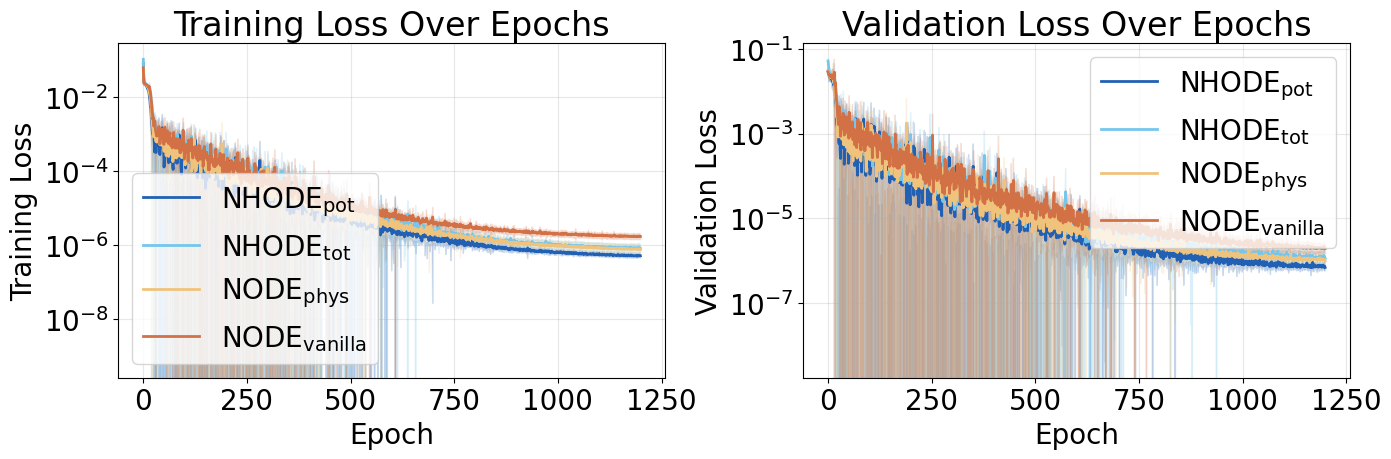

In [24]:
# Plot training and validation losses
plot_training_losses(method_to_checkpoints, log_scale=True)

### 8.3 Error Over Time

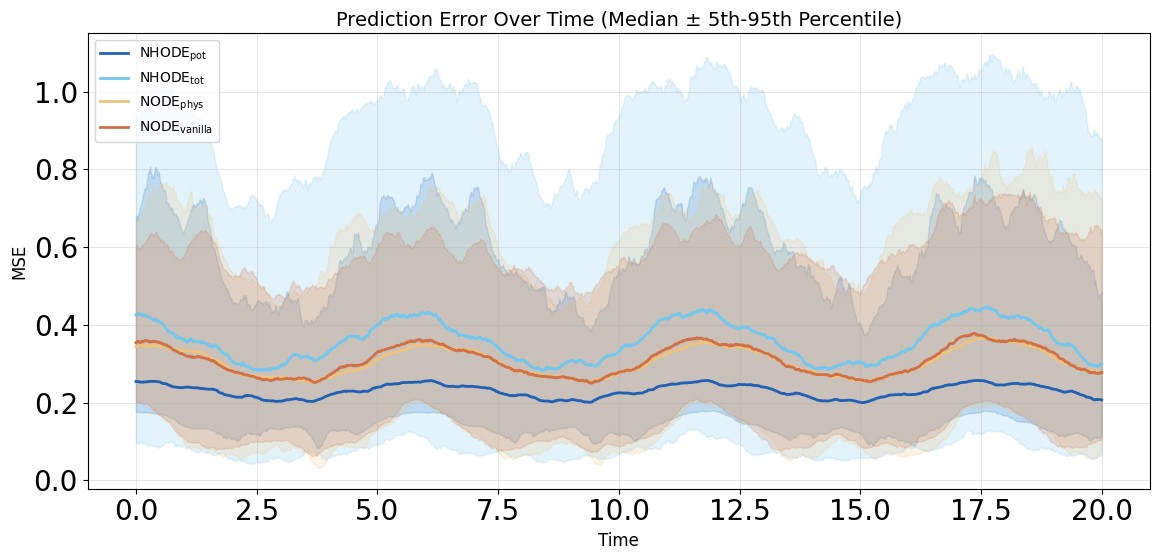

In [25]:
# Plot error over time with percentile bands
plot_error_over_time(results, times, use_percentiles=True, log_scale=False)

In [26]:
all_trajectories['hnn_pot']['all_predictions'].shape

(10, 100, 2001, 4)

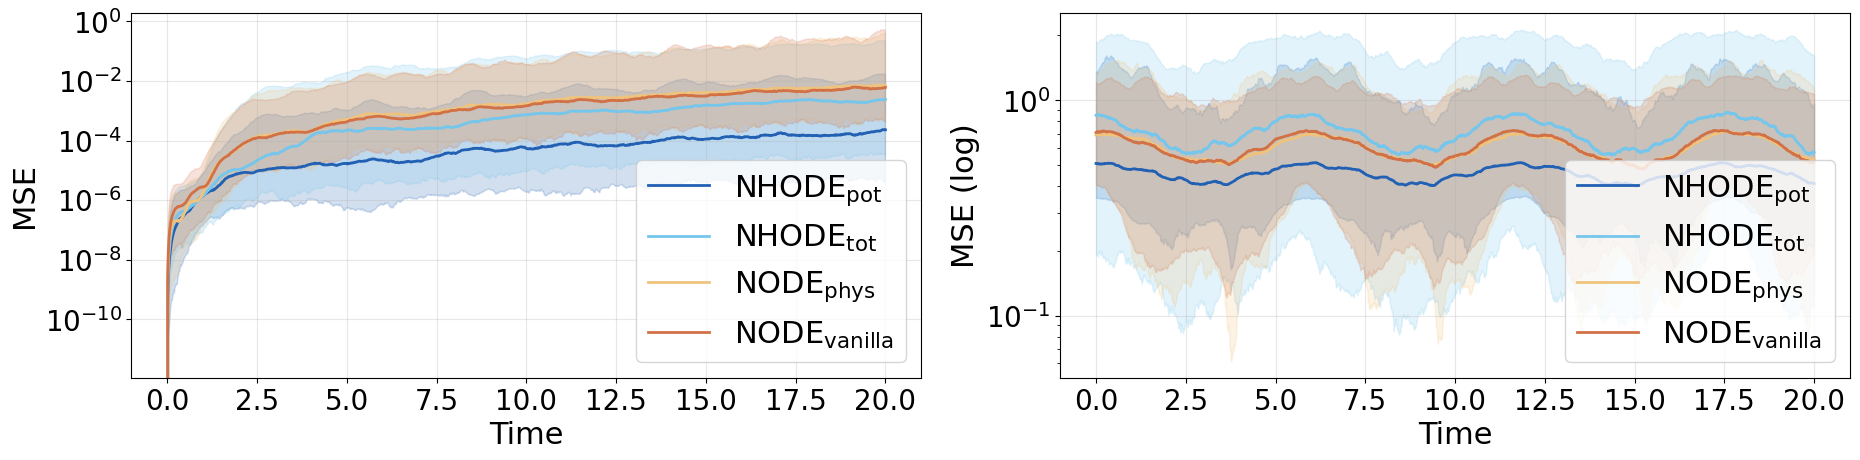

In [27]:
# Plot error comparison (linear and log scale)
plot_observed_and_unobserved_error_comparison(all_trajectories, times, figsize=(19, 5), fontsize=22)#, save_path='figures/without_regularisation/observed_unobserved_error_comparison.pdf')

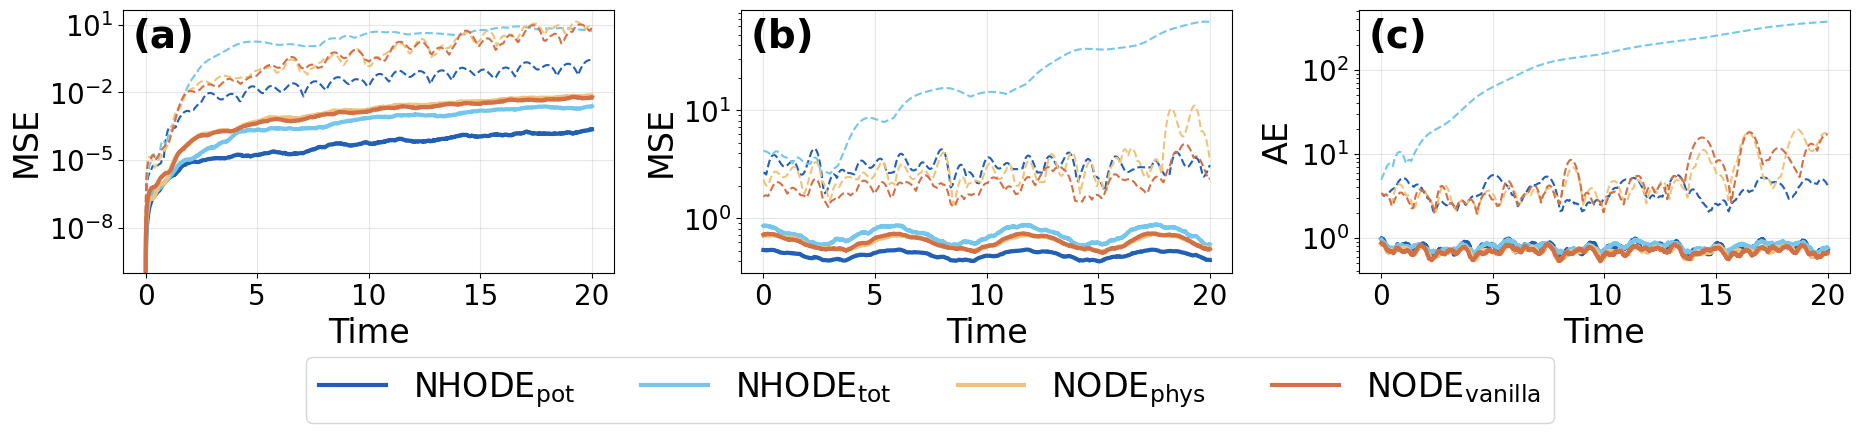

In [28]:
# plot observed vs unobserved vs energy error
plot_observed_vs_unobserved_vs_energy_error(results=all_trajectories, times=times, system_params=system_params, figsize=(19, 4), fontsize=24)#, save_path='figures/without_regularisation/observed_vs_unobserved_vs_energy_error.pdf')

In [29]:
print(times[2001])

20.0


In [30]:
# Print mean and std error after short and long period of time

T_short = 100 # t=2
T_long = 999 # t=20

for r in results:
    method = results[r]
    short_mean = method.mean_t[T_short]
    short_std = method.std_t[T_short]
    long_mean = method.mean_t[T_long]
    long_std = method.std_t[T_long]
    print(f"  Method: {r}")
    print(f"  Short (t={T_short}): mean={short_mean:.6e}, std={short_std:.6e}")
    print(f"  Long  (t={T_long}): mean={long_mean:.6e}, std={long_std:.6e}")
    print()


  Method: hnn_pot
  Short (t=100): mean=2.780018e-01, std=1.753113e-01
  Long  (t=999): mean=2.579349e-01, std=1.698494e-01

  Method: hnn_tot
  Short (t=100): mean=4.212105e-01, std=2.782055e-01
  Long  (t=999): mean=4.273152e-01, std=5.466396e-01

  Method: node_phys
  Short (t=100): mean=3.496541e-01, std=1.747527e-01
  Long  (t=999): mean=2.985861e-01, std=1.700863e-01

  Method: node_vanilla
  Short (t=100): mean=3.358092e-01, std=1.428651e-01
  Long  (t=999): mean=2.997563e-01, std=1.487027e-01



### 8.4 Trajectory Comparison

Pick a test trajectory and compare predicted trajectories from different methods.

In [31]:
#seed_number = 0
test_traj_number = 0

y_pred_dict = {}

for method, seed_dirs in method_to_checkpoints.items():

    # Use first seed
    #seed_dir = seed_dirs[seed_number]

    #predictions = all_trajectories[method]["all_predictions"][seed_number][test_traj_number]
    predictions = all_trajectories[method]["median_prediction"][test_traj_number]
    all_true = all_trajectories[method]["all_true"][test_traj_number]

    y_pred_dict[method] = predictions


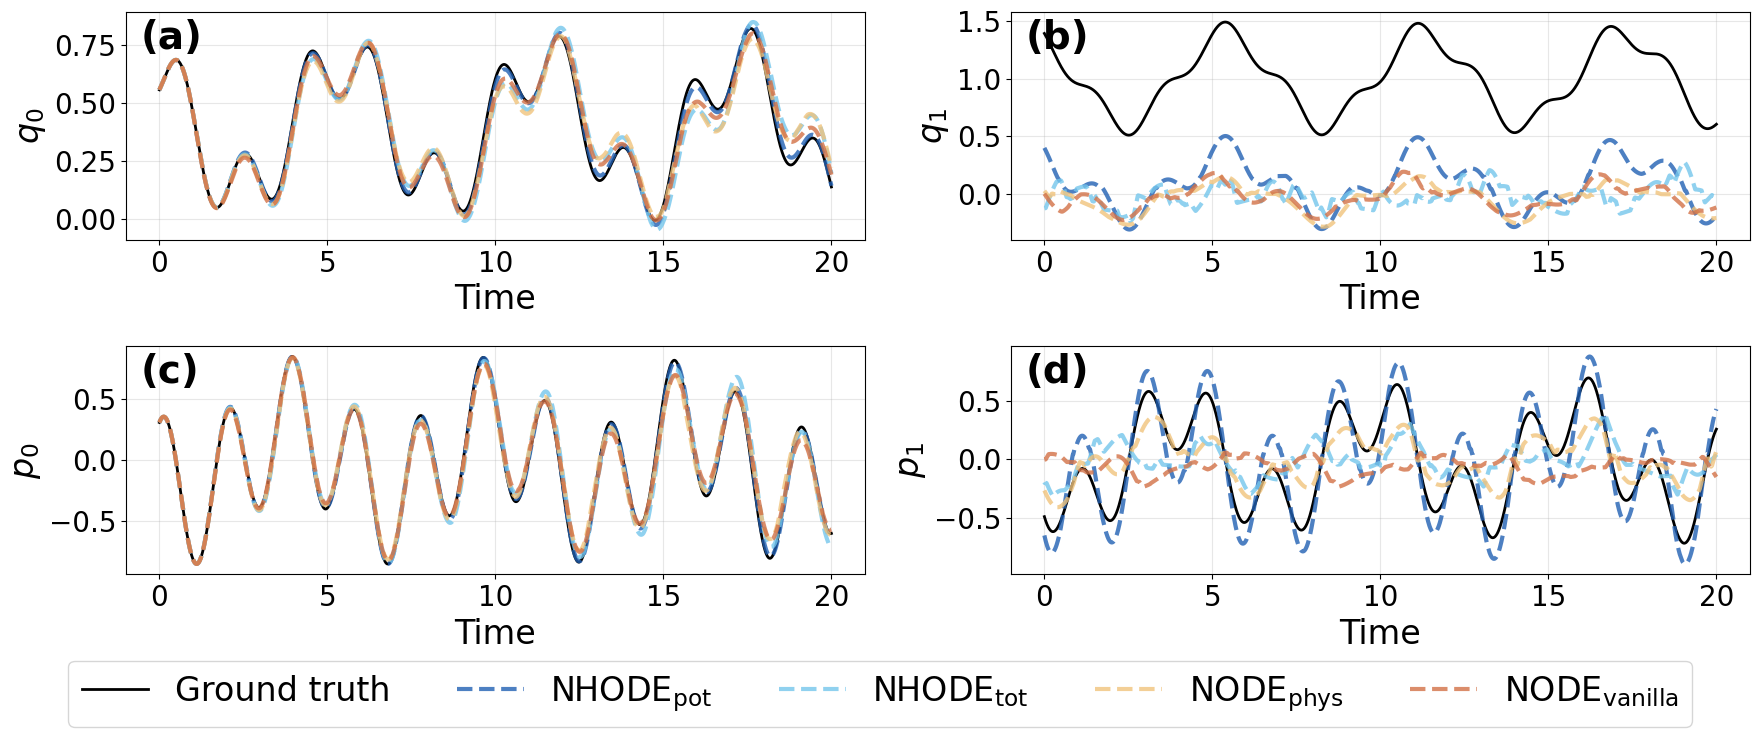

In [32]:
# Plot all components in grid
plot_all_components_grid(all_true, y_pred_dict, times, 
                        component_names=['$q_0$', '$q_1$', '$p_0$', '$p_1$'], fontsize=24, figsize=(18, 7))#, save_path='figures/without_regularisation/pred_trajectory_all_components.pdf')

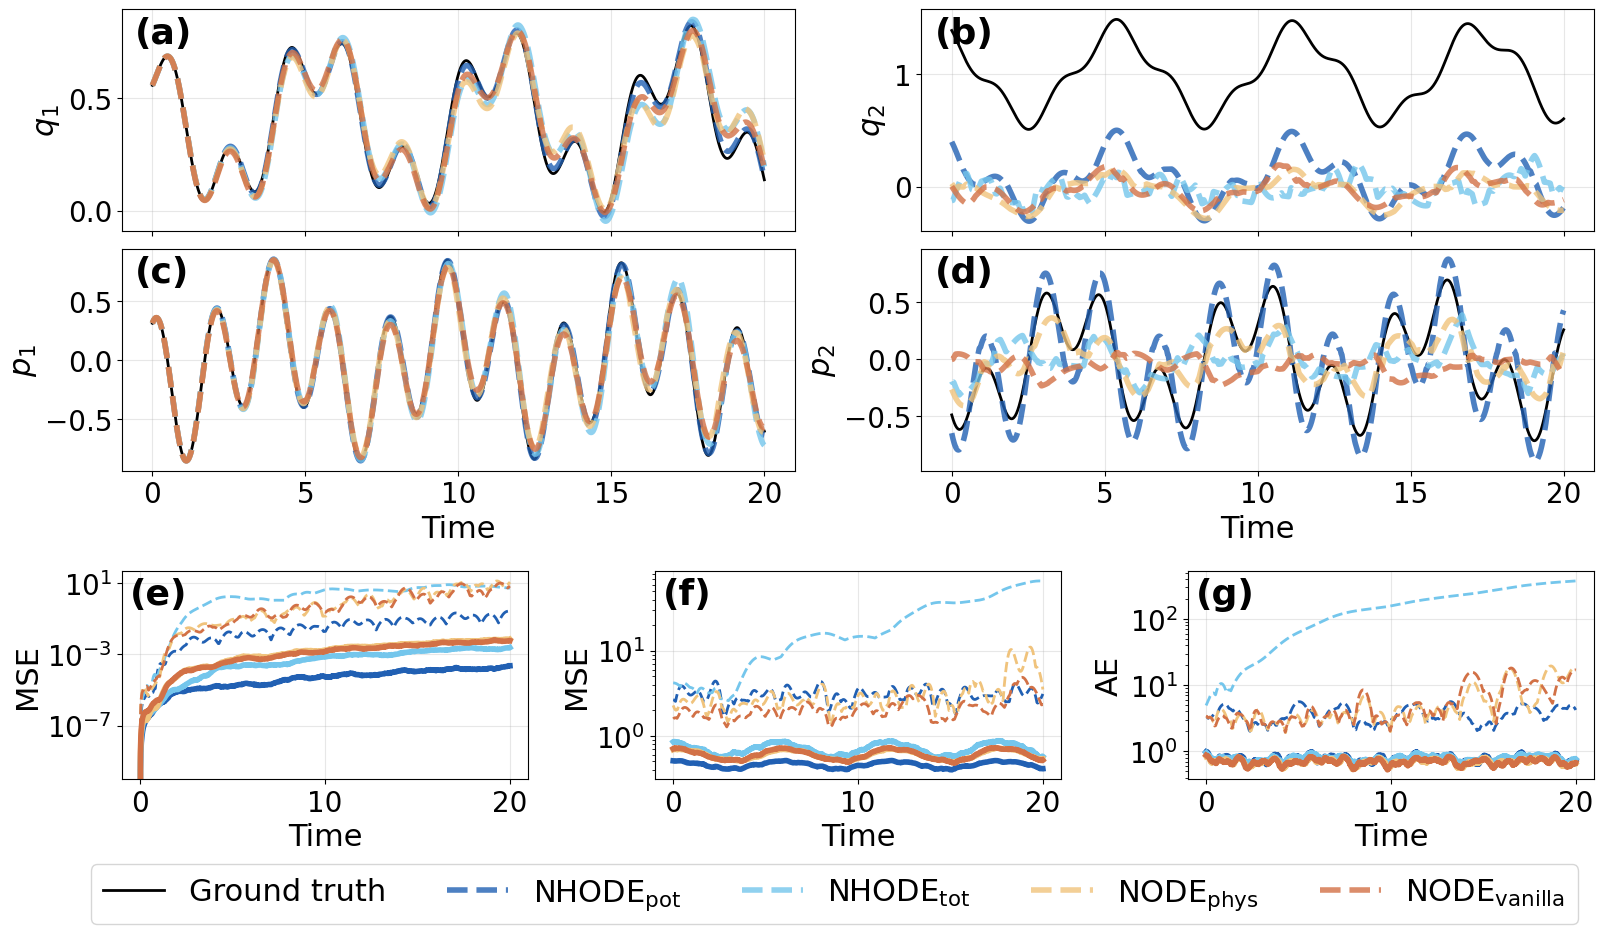

In [40]:
plot_combined_trajectory_and_errors(
    y_true=all_true,
    y_pred_dict=y_pred_dict,
    times=times,
    all_trajectories=all_trajectories,
    system_params=system_params,
    component_names=['$q_1$', '$q_2$', '$p_1$', '$p_2$'],
    figsize=(19, 10),
    height_ratio_top=1.0,
    height_ratio_bot=0.9,
    fontsize=22,
    #save_path=Path('figures/combined_trajectory_grid_and_errors_v2.pdf'),
)

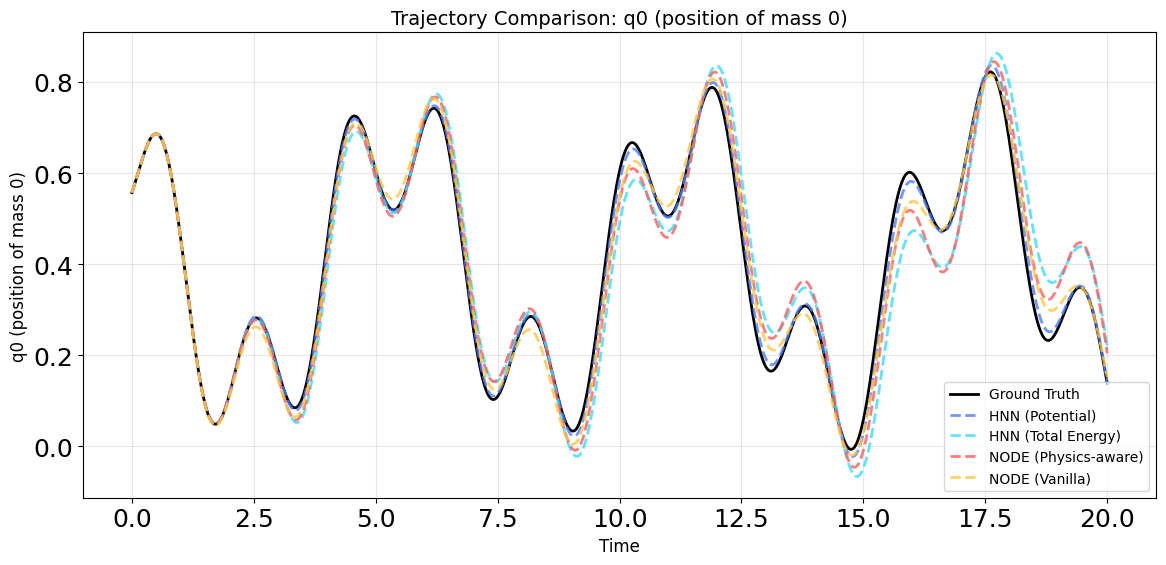

In [33]:
# Plot individual 1D trajectories
plot_1d_trajectory(all_true, y_pred_dict, times, 
                  component_idx=0, component_name='q0 (position of mass 0)')

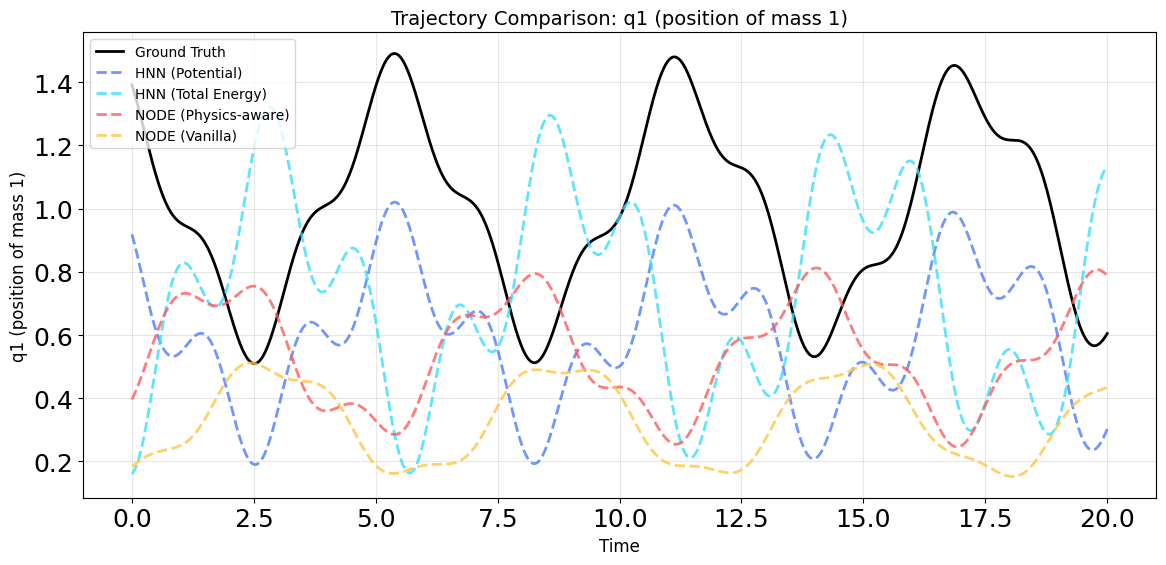

In [34]:
plot_1d_trajectory(all_true, y_pred_dict, times,
                  component_idx=1, component_name='q1 (position of mass 1)')

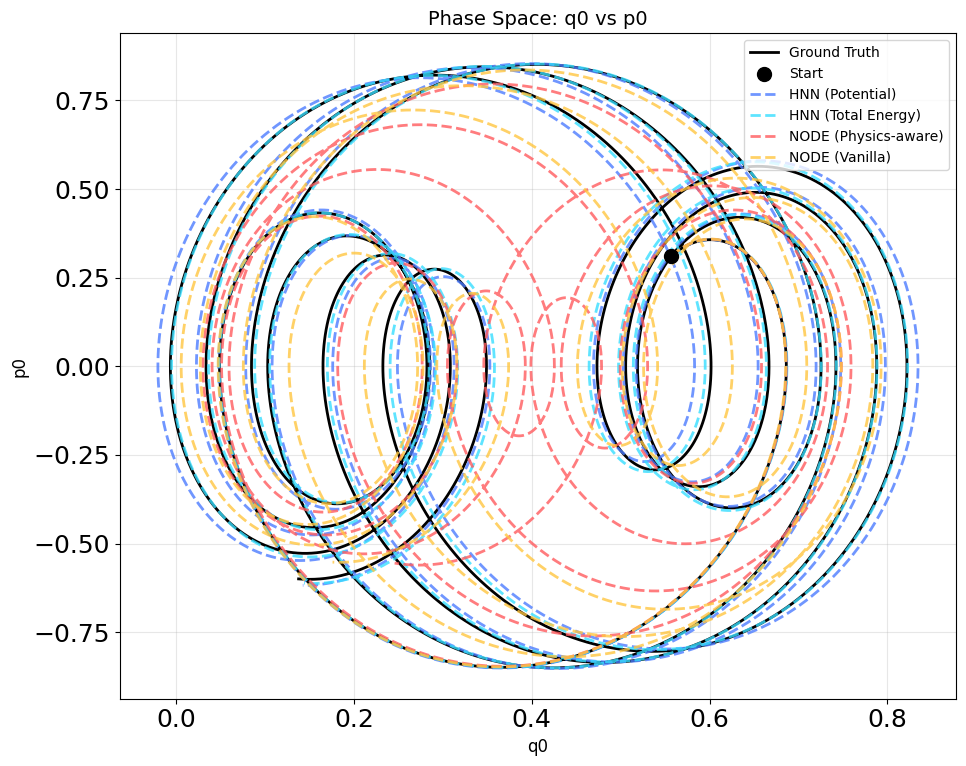

In [ ]:
# Plot phase space for mass 0
plot_phase_space(all_true, y_pred_dict, 
                pos_idx=0, mom_idx=2, pos_name='q0', mom_name='p0')#, save_path='figures/with_regularisation/phase_space_mass_0.pdf')

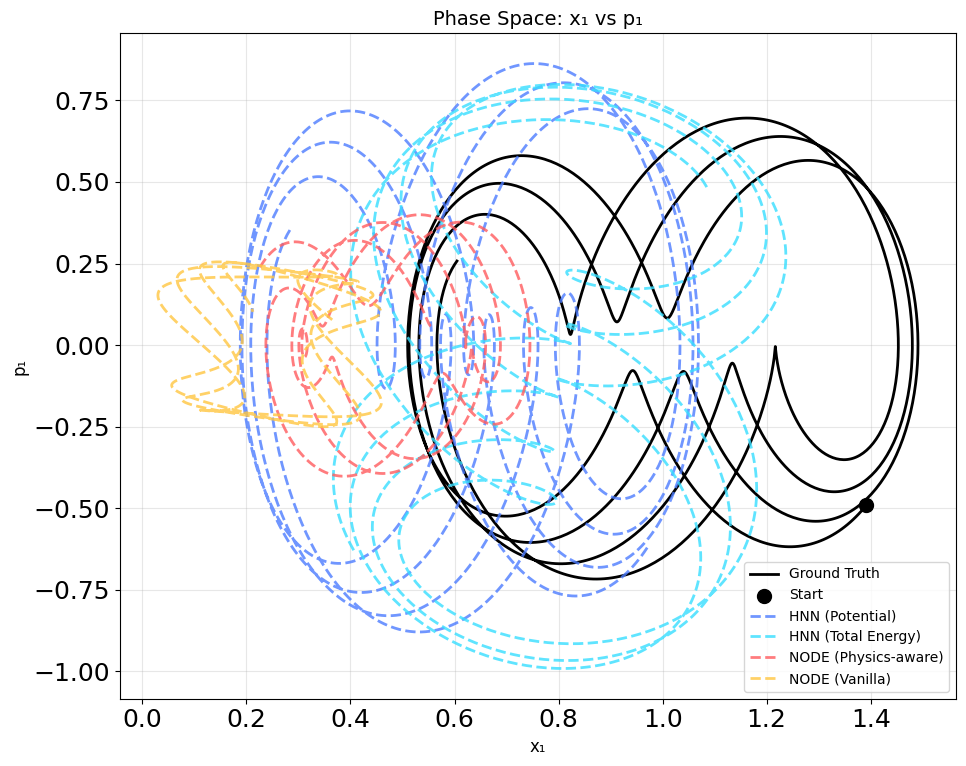

In [ ]:
# Plot phase space for mass 1
plot_phase_space(all_true, y_pred_dict,
                pos_idx=1, mom_idx=3, pos_name='x₁', mom_name='p₁')#, save_path='figures/with_regularisation/phase_space_mass_1.pdf')